# Explainable, Edge-Efficient Olive Leaf Disease Classification

Integration notebook for the project. The tested implementations under
`compression/src/`, `analysis/` and `leaf_segmenter/` remain the authoritative
source; this notebook orchestrates them from reproducible cells and presents
their saved results in one place.

The two research questions from the proposal are answered in sections 3-5 (RQ a)
and section 6 (RQ b):

**RQ a.** How effectively do ImageNet-pretrained CNN architectures transfer to
olive leaf disease classification compared with training from scratch and with an
interpretable glass-box baseline, and what do XAI techniques reveal about them?

**RQ b.** To what extent can post-training quantisation and pruning reduce model
size and inference latency while preserving accuracy and explanation fidelity?

> Before submission, the team must replace this note with its own introduction,
> AI-use declaration, interpretation, conclusion, and individual contributions.

## 0. Environment and execution controls

### Dataset

Olive Leaf Image Dataset, published on Kaggle as
`habibulbasher01644/olive-leaf-image-dataset` under **CC0 / public domain**. CC0
imposes no legal attribution requirement; it is cited here as an academic norm.
The archive ships its own `train/` and `test/` folders, and **that official test
split is preserved unchanged throughout** — de-duplication removes training
images only, so every test figure in this notebook is comparable with other work
on the same dataset.

### Environment

Everything runs inside the course image, unmodified, with no packages installed:

| | |
|---|---|
| Image | `kquille/hcaim_gpu_tudublin_course:latest` |
| Python | 3.8.10 |
| TensorFlow | 2.12.0 (CPU only; `list_physical_devices('GPU')` returns `[]`) |
| scikit-learn / scikit-image / SciPy | 1.2.2 / 0.21.0 / 1.10.1 |
| NumPy / pandas / matplotlib / Pillow | 1.22.3 / 2.0.2 / 3.7.1 / 9.4.0 |
| XAI | `lime`, `shap` 0.41.0, `tf-keras-vis` 0.8.5 |

Start Jupyter from the repository root — the first cell fails deliberately if the
working directory is anywhere else:

```bash
docker run --rm -it -p 8888:8888 \
    --user "$(id -u):$(id -g)" -e HOME=/tmp \
    -v "$PWD:$PWD" -w "$PWD" \
    kquille/hcaim_gpu_tudublin_course:latest \
    jupyter notebook --ip 0.0.0.0 --no-browser
```

To re-execute the whole notebook without a browser:

```bash
docker run --rm --user "$(id -u):$(id -g)" -e HOME=/tmp \
    -v "$PWD:$PWD" -w "$PWD" \
    kquille/hcaim_gpu_tudublin_course:latest \
    python -m nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=1800 \
    Olive_Leaf_Final_Integrated_Notebook.ipynb
```

### What to enable, and in what order

Every expensive stage is off by default because its results are committed. With
all flags `False` the notebook reads saved artefacts and runs in under a minute.
To regenerate from the raw archive, enable the flags **in this order** — each
stage consumes the previous stage's output:

| order | flag | needs | produces | cost (20-core CPU) |
|---|---|---|---|---|
| 1 | `RUN_DATA_PREPARATION` | `olive-leaf-image-dataset.zip` at the repo root | manifests, `data/prepared/images/` | ~1 min |
| 2 | `RUN_SEGMENTATION` | `yolo_segmenter_weights.pt` (**not in the repository**) | `olive_leaf_dataset/segmented/` | GPU-dependent |
| 3 | `RUN_SCRATCH_TRAINING` | stage 1 | `scratch_*_baseline` models + metrics | ~45 min per architecture |
| 4 | `RUN_TRAINING` | stage 1 | `mobilenetv2` / `densenet121` models | ~20 min / ~60 min |
| 5 | `RUN_COMPRESSION` | stage 4 | TFLite variants, pruning sweeps, latency | longest stage; not timed |
| 6 | `RUN_ANALYSIS` | stages 1, 2, 4 | glass-box, Grad-CAM, bias results | ~20 min |

Stages 3 and 4 are measured: their `train_seconds` are in the result JSONs and
reproduced in the table in section 3. Stage 5 was never timed end to end — it is
dominated by the recovery training inside the pruning sweeps, eight fine-tuning
runs in total, so it is the longest of the six. Stages 1 and 6 are quoted from
observation rather than instrumentation.

Stage 2 is the one gap in reproducibility from this repository alone: the
segmenter weights are a fine-tuning artefact that is not version-controlled, so
its crops are treated as a fixed input. Stages 3-6 do not depend on re-running
it, because the crops themselves are committed.

In [1]:
from collections import Counter
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'compression' / 'src').is_dir():
    raise RuntimeError('Start Jupyter from the repository root, not from a subdirectory.')

COMPRESSION_DIR = REPO_ROOT / 'compression'
ANALYSIS_DIR = REPO_ROOT / 'analysis'
SEGMENTER_DIR = REPO_ROOT / 'leaf_segmenter'
COMPRESSION_RESULTS = COMPRESSION_DIR / 'results'
ANALYSIS_RESULTS = ANALYSIS_DIR / 'results'
PREPARED_DIR = COMPRESSION_DIR / 'data' / 'prepared'
SEGMENTED_CROPS = REPO_ROOT / 'olive_leaf_dataset' / 'segmented' / 'train'

CLASSES = ('Healthy', 'aculus_olearius', 'olive_peacock_spot')
BACKBONES = ('mobilenetv2', 'densenet121')
SCRATCH_ARCHS = ('original', 'improved')

RUN_DATA_PREPARATION = False   # about one minute
RUN_SEGMENTATION = False       # needs YOLO weights that are not in the repository
RUN_SCRATCH_TRAINING = False   # roughly 45 minutes per architecture on CPU
RUN_TRAINING = False           # roughly 1-3 hours per backbone on CPU
RUN_COMPRESSION = False        # conversion, pruning sweeps, and measurement
RUN_ANALYSIS = False           # glass-box, bias, and Grad-CAM analyses

print('Repository:', REPO_ROOT)
print('Python:', sys.version.split()[0])

Repository: /home/test/CA3
Python: 3.8.10


In [2]:
def run_source(workdir, script, *args):
    """Run one authoritative project module with this notebook's interpreter."""
    command = [sys.executable, script, *map(str, args)]
    print('$', ' '.join(command), f'(cwd={workdir})')
    return subprocess.run(command, cwd=workdir, check=True)


def load_json(path):
    with Path(path).open(encoding='utf-8') as handle:
        return json.load(handle)


def needs(*paths, hint=''):
    """Return the paths if all of them exist, otherwise explain and return None.

    Trained models (394 MB) and the prepared image copies (95 MB) are too large
    to keep in the repository, so a fresh clone legitimately does not have them.
    Cells guard their inputs with this helper so that `Restart & Run All` still
    completes on such a clone: the stages whose inputs are absent say what to
    enable instead of aborting the whole run with a traceback.
    """
    resolved = [Path(p) for p in paths]
    missing = [p for p in resolved if not p.exists()]
    if missing:
        print('SKIPPED - not present in this working copy:')
        for path in missing:
            print('   ', path.relative_to(REPO_ROOT))
        if hint:
            print('   ->', hint)
        return None
    return resolved

In [3]:
# What this working copy actually holds. Everything marked "regenerate" below is
# either too large for version control or too slow to run on every clone; the
# committed JSON/CSV/PNG results are what the report is built from.
STAGES = [
    ('split manifests and statistics', 'RUN_DATA_PREPARATION',
     [PREPARED_DIR / 'stats.json', PREPARED_DIR / 'manifest_trainval.csv']),
    ('prepared image copies (not in git)', 'RUN_DATA_PREPARATION',
     [PREPARED_DIR / 'images']),
    ('dataset audit', 'RUN_ANALYSIS', [ANALYSIS_RESULTS / 'dataset_audit.json']),
    ('segmented leaf crops (not in git)', 'RUN_SEGMENTATION', [SEGMENTED_CROPS]),
    ('deep model metrics', 'RUN_TRAINING / RUN_SCRATCH_TRAINING',
     [COMPRESSION_RESULTS / ('%s_baseline.json' % b) for b in BACKBONES]),
    ('trained models (not in git)', 'RUN_TRAINING',
     [COMPRESSION_DIR / 'artifacts']),
    ('glass-box results', 'RUN_ANALYSIS',
     [ANALYSIS_RESULTS / 'glassbox_fixed.json',
      ANALYSIS_RESULTS / 'glassbox_common_protocol.json']),
    ('compression tables and figures', 'RUN_COMPRESSION',
     [COMPRESSION_RESULTS / 'compression_tradeoff.png']),
    ('Grad-CAM and bias analyses', 'RUN_ANALYSIS',
     [ANALYSIS_RESULTS / 'gradcam_report.json',
      ANALYSIS_RESULTS / 'acquisition_bias.json']),
]

availability = pd.DataFrame([
    {'stage': name,
     'present': all(p.exists() for p in paths),
     'regenerate with': flag}
    for name, flag, paths in STAGES
]).set_index('stage')
display(availability)

,present,regenerate with
stage,,
split manifests and statistics,True,RUN_DATA_PREPARATION
prepared image copies (not in git),True,RUN_DATA_PREPARATION
dataset audit,True,RUN_ANALYSIS
segmented leaf crops (not in git),True,RUN_SEGMENTATION
deep model metrics,True,RUN_TRAINING / RUN_SCRATCH_TRAINING
trained models (not in git),True,RUN_TRAINING
glass-box results,True,RUN_ANALYSIS
compression tables and figures,True,RUN_COMPRESSION
Grad-CAM and bias analyses,True,RUN_ANALYSIS


## 1. Dataset audit and leakage-safe preparation

The original archive contains exact and re-encoded duplicates across train and
test, as well as burst photographs of the same leaf.
`compression/src/prepare_data.py` removes affected training images, leaves the
official test split intact, and creates a stratified group-aware
train/validation split. `analysis/dataset_audit.py` checks integrity,
dimensions, formats, colour statistics, and capture-source bias.

In [4]:
if RUN_DATA_PREPARATION:
    run_source(COMPRESSION_DIR, 'src/prepare_data.py')
    run_source(ANALYSIS_DIR, 'dataset_audit.py')

In [5]:
found = needs(PREPARED_DIR / 'stats.json', ANALYSIS_RESULTS / 'dataset_audit.json',
              hint='enable RUN_DATA_PREPARATION and RUN_ANALYSIS')
if found:
    stats, audit = (load_json(p) for p in found)

    split_table = pd.DataFrame([
        {'class': class_name,
         'original train': stats['train_original'][class_name],
         'after de-duplication': stats['train_after_dedup'][class_name],
         'train': stats['train_split'][class_name],
         'validation': stats['val_split'][class_name],
         'test': stats['test'][class_name]}
        for class_name in CLASSES
    ]).set_index('class')
    display(split_table)

    quality_table = pd.DataFrame({
        'check': ['corrupt images', 'distinct dimensions', 'formats', 'colour modes'],
        'result': [
            audit['corrupt']['count'],
            audit['dimensions']['distinct'],
            ', '.join(audit['formats']),
            ', '.join(audit['modes']),
        ],
    })
    display(quality_table)

,original train,after de-duplication,train,validation,test
class,,,,,
Healthy,830,723,578,145,220
aculus_olearius,690,684,547,137,200
olive_peacock_spot,1200,954,763,191,260


,check,result
0,corrupt images,0
1,distinct dimensions,1
2,formats,JPEG
3,colour modes,RGB


### Preprocessing used by every deep model

`compression/src/common.py` is the single source of truth for the manifests,
224x224 input size, backbone-specific ImageNet preprocessing, training-only
augmentation, balanced class weights, and accuracy/macro-F1/per-class-recall
evaluation. Every deep model in section 3 -- including the one trained from
scratch -- goes through it, so preprocessing differences cannot be mistaken for
architecture or compression effects.

## 2. Leaf segmentation

The glass-box features in section 4 are extracted from single-leaf crops rather
than whole photographs, and producing those crops is a modelling problem in its
own right. `leaf_segmenter/` contains the survey it grew from -- eleven
configurations across five model families, benchmarked on the CVPPP A1 split
against leaf-count (DiC) and mask-quality (FBD, SBD) ground truth -- and
`Leaf_Segmenter.ipynb` applies the selected model to the olive photographs.

The headline table below is parsed directly out of
`leaf_segmenter/eval/evaluation_report.md` rather than retyped, so the notebook
cannot drift from the evaluation that produced it.

In [6]:
def markdown_table(path, heading):
    """Read the first markdown table under a heading, as a DataFrame.

    Parsing the report keeps a single source of truth for these numbers: they
    are produced by `leaf_segmenter/eval/*.py` and written there, so retyping
    them into the notebook would create a second copy that can silently drift.
    """
    text = Path(path).read_text(encoding='utf-8')
    body = text.split(heading, 1)[1]
    rows, started = [], False
    for line in body.splitlines():
        stripped = line.strip()
        if stripped.startswith('|'):
            started = True
            # '\|' inside a cell (as in |DiC|) must survive the column split.
            cells = stripped.replace('\\|', '\x00').strip('|').split('|')
            rows.append([c.strip().replace('**', '').replace('\x00', '|') for c in cells])
        elif started:
            break
    header, _separator, *data = rows
    return pd.DataFrame(data, columns=header)


found = needs(SEGMENTER_DIR / 'eval' / 'evaluation_report.md',
              hint='leaf_segmenter/eval/evaluation_report.md is committed; check the path')
if found:
    display(markdown_table(found[0], '## Headline comparison'))

,Model (best variant),FBD ↑,SBD ↑,|DiC| ↓,Speed (s/img) ↓,Needs labels?
0,YOLO11-seg (fine-tuned),0.958,0.847,1.98,0.015,yes
1,Mask R-CNN (fine-tuned),0.952,0.832,1.24,0.068,yes
2,SAM2 (base-plus),0.845,0.601,4.59,3.884,no
3,Leaf Only SAM (vit_b),0.519,0.336,10.70,8.903,no
4,Mask2Former (COCO only),0.401,0.040,14.18,0.035,*needs fine-tune*


In [7]:
if RUN_SEGMENTATION:
    # Left off by default: Leaf_Segmenter.ipynb loads yolo_segmenter_weights.pt,
    # which is a fine-tuning artefact that is not in the repository. The crops it
    # produced are the durable output and are what section 4 consumes.
    print('Run leaf_segmenter/Leaf_Segmenter.ipynb with yolo_segmenter_weights.pt present.')

found = needs(SEGMENTER_DIR / 'seg_result.csv',
              hint='enable RUN_SEGMENTATION, or use the committed crops')
if found:
    segmentation = pd.read_csv(found[0])
    per_photo = (segmentation['n_leaves'].value_counts().sort_index()
                 .rename('photographs').rename_axis('leaves detected').to_frame())
    per_photo['share'] = (per_photo['photographs'] / len(segmentation)).round(3)
    print('%d training photographs segmented, %d leaf crops emitted'
          % (len(segmentation), int(segmentation['n_leaves'].sum())))
    display(per_photo)

crops = needs(SEGMENTED_CROPS, hint='enable RUN_SEGMENTATION to regenerate the crops')
if crops:
    # When the segmenter finds nothing, the pipeline falls back to writing the
    # whole photograph as `<stem>_full.png`. Those files sit in the same folders
    # as the real crops, so they have to be counted separately or the crop set
    # looks cleaner than it is.
    crop_rows = []
    for class_name in CLASSES:
        files = sorted((crops[0] / class_name).iterdir())
        fallbacks = [f for f in files if f.stem.endswith('_full')]
        crop_rows.append({'class': class_name, 'files': len(files),
                          'single-leaf crops': len(files) - len(fallbacks),
                          'whole-image fallbacks': len(fallbacks)})
    crop_table = pd.DataFrame(crop_rows).set_index('class')
    crop_table.loc['total'] = crop_table.sum()
    display(crop_table)

2720 training photographs segmented, 2677 leaf crops emitted


,photographs,share
leaves detected,,
0,326,0.120
1,2127,0.782
2,252,0.093
3,14,0.005
4,1,0.000


,files,single-leaf crops,whole-image fallbacks
class,,,
Healthy,899,845,54
aculus_olearius,761,666,95
olive_peacock_spot,1343,1166,177
total,3003,2677,326


Three consequences carry into the rest of the notebook.

First, 326 of the 2,720 photographs (12%) yielded no leaf at all and 267 yielded
more than one, so the crop set is neither a subset nor a relabelling of the
photograph set -- it is a different population. That is why section 4 evaluates
the glass-box models under two protocols rather than one.

Second, the two counts above reconcile exactly: 3,003 files = 2,677 detected
leaves + 326 whole-image fallbacks. So about 11% of the files feeding the
glass-box features (326 of 3,003) are unsegmented photographs, complete with
background. Given how strongly capture source correlates with class in this
dataset (section 8), that is a route by which background rather than leaf
condition can drive a glass-box prediction -- and it is visible in the
individual explanations, where GLCM texture features computed over the whole
crop carry weight.

Third, the segmenter was fine-tuned on labelled data and its weights
(`yolo_segmenter_weights.pt`) are not in the repository, so the crops are
treated as a fixed input here rather than something this notebook regenerates.

## 3. Deep models: from scratch against transfer learning

RQ a asks how ImageNet transfer compares *with training from scratch*, so both
are trained here on the identical leakage-free split.

`compression/src/train_scratch.py` provides two randomly initialised networks.
**original** is a faithful reproduction of the architecture selected in
`Olive_Leaf_CNN_Model_Notebook.ipynb` (cell 16): two 5x5 convolutions, spatial
dropout, then `Flatten` into `Dense(64)`, which alone costs 5.75M of its 5.77M
parameters. **improved** spends a tenth of that budget on depth instead -- a
strided stem, four convolutional stages with BatchNorm, and global average
pooling. Reproducing the original architecture unchanged is what isolates the
effect of the corrected data and protocol from the effect of the architecture.

`compression/src/train_baseline.py` implements the two-stage transfer learning:
train a classification head on a frozen ImageNet backbone, then fine-tune only
the final block at a lower learning rate with BatchNorm frozen. MobileNetV2 is
the edge-oriented primary model; DenseNet121 is the heavier comparison.

In [8]:
if RUN_SCRATCH_TRAINING:
    for arch in SCRATCH_ARCHS:
        run_source(COMPRESSION_DIR, 'src/train_scratch.py', '--arch', arch)

if RUN_TRAINING:
    for backbone in BACKBONES:
        run_source(COMPRESSION_DIR, 'src/train_baseline.py', '--backbone', backbone)

In [9]:
DEEP_MODELS = [
    ('scratch CNN (notebook architecture)', 'from scratch', 'scratch_original_baseline.json'),
    ('scratch CNN (redesigned)', 'from scratch', 'scratch_improved_baseline.json'),
    ('MobileNetV2', 'ImageNet transfer', 'mobilenetv2_baseline.json'),
    ('DenseNet121', 'ImageNet transfer', 'densenet121_baseline.json'),
]

deep_rows = []
for name, training, filename in DEEP_MODELS:
    found = needs(COMPRESSION_RESULTS / filename,
                  hint='enable RUN_SCRATCH_TRAINING / RUN_TRAINING')
    if not found:
        continue
    result = load_json(found[0])
    test = result['metrics']['test']
    deep_rows.append({
        'model': name,
        'initialisation': training,
        'parameters': result['total_parameters'],
        'train seconds': result['train_seconds'],
        'validation macro-F1': result['metrics']['val']['macro_f1'],
        'test accuracy': test['accuracy'],
        'test macro-F1': test['macro_f1'],
        'Aculus recall': test['per_class_recall']['aculus_olearius'],
    })

deep_table = pd.DataFrame(deep_rows).set_index('model')
display(deep_table.style.format(precision=4))

,initialisation,parameters,train seconds,validation macro-F1,test accuracy,test macro-F1,Aculus recall
model,,,,,,,
scratch CNN (notebook architecture),from scratch,5767139,2687.3000,0.7765,0.8118,0.8095,0.7350
scratch CNN (redesigned),from scratch,585059,2632.5000,0.9162,0.8706,0.8712,0.8300
MobileNetV2,ImageNet transfer,2261827,1175.2000,0.9142,0.9309,0.9296,0.8850
DenseNet121,ImageNet transfer,7040579,3459.6000,0.9237,0.9397,0.9387,0.9700


## 4. Glass-box baselines

`analysis/glassbox_fixed.py` extracts named colour and GLCM texture features and
fits both a Decision Tree and a Logistic Regression. It replaces the original
glass-box notebook, whose exported filenames are misaligned with shuffled labels
and whose random crop split leaks source photographs across the train/test
boundary.

It runs under two protocols, and the difference between them is a result, not
bookkeeping:

* **segmented** -- the setting the features were designed for: one crop per
  detected leaf, held out with `StratifiedGroupKFold` grouped on the source
  photograph so sibling crops cannot straddle the split.
* **common** -- the same features and models over exactly the manifests the deep
  models use, scored on the official 680-image test split. This is the protocol
  that makes section 5's comparison like-for-like.

In [10]:
if RUN_ANALYSIS:
    run_source(ANALYSIS_DIR, 'glassbox_fixed.py')
    run_source(ANALYSIS_DIR, 'glassbox_fixed.py', '--protocol', 'common')

In [11]:
GLASSBOX_FILES = {'segmented': 'glassbox_fixed.json',
                  'common': 'glassbox_common_protocol.json'}

glassbox = {}
for protocol, filename in GLASSBOX_FILES.items():
    found = needs(ANALYSIS_RESULTS / filename, hint='enable RUN_ANALYSIS')
    if found:
        glassbox[protocol] = load_json(found[0])

glassbox_rows = []
for protocol, result in glassbox.items():
    for model in ('decision_tree', 'logistic_regression'):
        glassbox_rows.append({
            'protocol': protocol,
            'model': model.replace('_', ' '),
            'test images': result['split']['test'],
            'accuracy': result[model]['accuracy'],
            'macro-F1': result[model]['macro_f1'],
        })
display(pd.DataFrame(glassbox_rows).set_index(['protocol', 'model'])
        .style.format(precision=4))

for protocol, result in glassbox.items():
    print('%s protocol: %s, source photographs shared across the split: %d'
          % (protocol, result['split']['note'], result['split']['shared_groups']))

segmented protocol: StratifiedGroupKFold on the source photograph, source photographs shared across the split: 0
common protocol: official test split from compression/data/prepared manifests, source photographs shared across the split: 0


In [12]:
# The global glass-box explanation: what each feature is worth to each class.
if 'common' in glassbox:
    coefficients = pd.DataFrame(glassbox['common']['logistic_regression_coefficients']).T
    coefficients.index.name = 'feature'
    display(coefficients.style.background_gradient(cmap='RdBu', axis=None).format(precision=3))
    print(glassbox['common']['decision_tree_rules'])

,Healthy,aculus_olearius,olive_peacock_spot
feature,,,
frac_green,0.506,0.808,-1.314
frac_yellow,-1.305,0.242,1.063
frac_brown,0.234,-0.511,0.277
frac_dark,0.126,-0.267,0.141
frac_gray,-0.514,0.489,0.025
glcm_contrast,-0.293,0.229,0.064
glcm_homogeneity,-0.075,-0.349,0.424
glcm_energy,0.295,-0.087,-0.208
glcm_correlation,0.001,-0.169,0.168


|--- frac_yellow <= 0.01
|   |--- frac_brown <= 0.00
|   |   |--- glcm_energy <= 0.14
|   |   |   |--- class: 2
|   |   |--- glcm_energy >  0.14
|   |   |   |--- class: 1
|   |--- frac_brown >  0.00
|   |   |--- frac_gray <= 0.82
|   |   |   |--- class: 0
|   |   |--- frac_gray >  0.82
|   |   |   |--- class: 0
|--- frac_yellow >  0.01
|   |--- glcm_contrast <= 4.00
|   |   |--- frac_green <= 0.11
|   |   |   |--- class: 2
|   |   |--- frac_green >  0.11
|   |   |   |--- class: 0
|   |--- glcm_contrast >  4.00
|   |   |--- frac_green <= 0.09
|   |   |   |--- class: 2
|   |   |--- frac_green >  0.09
|   |   |   |--- class: 1



### Individual predictions

Coefficients and a rule list describe the model; they do not explain any
particular decision. The rubric asks for both, so `glassbox_fixed.py` also
selects two correct and two incorrect test predictions per model and decomposes
each one. For the Logistic Regression the decomposition is exact -- the score is
a sum, so each bar is `coefficient x standardised feature value` with no
surrogate involved, unlike the LIME approximations used for the deep models in
section 7. For the Decision Tree the bars show how far the sample sat from each
threshold on the path it actually took.

Shown here under the **segmented** protocol, the setting the features were
designed for; the common-protocol equivalents are displayed in section 5
alongside the like-for-like comparison.

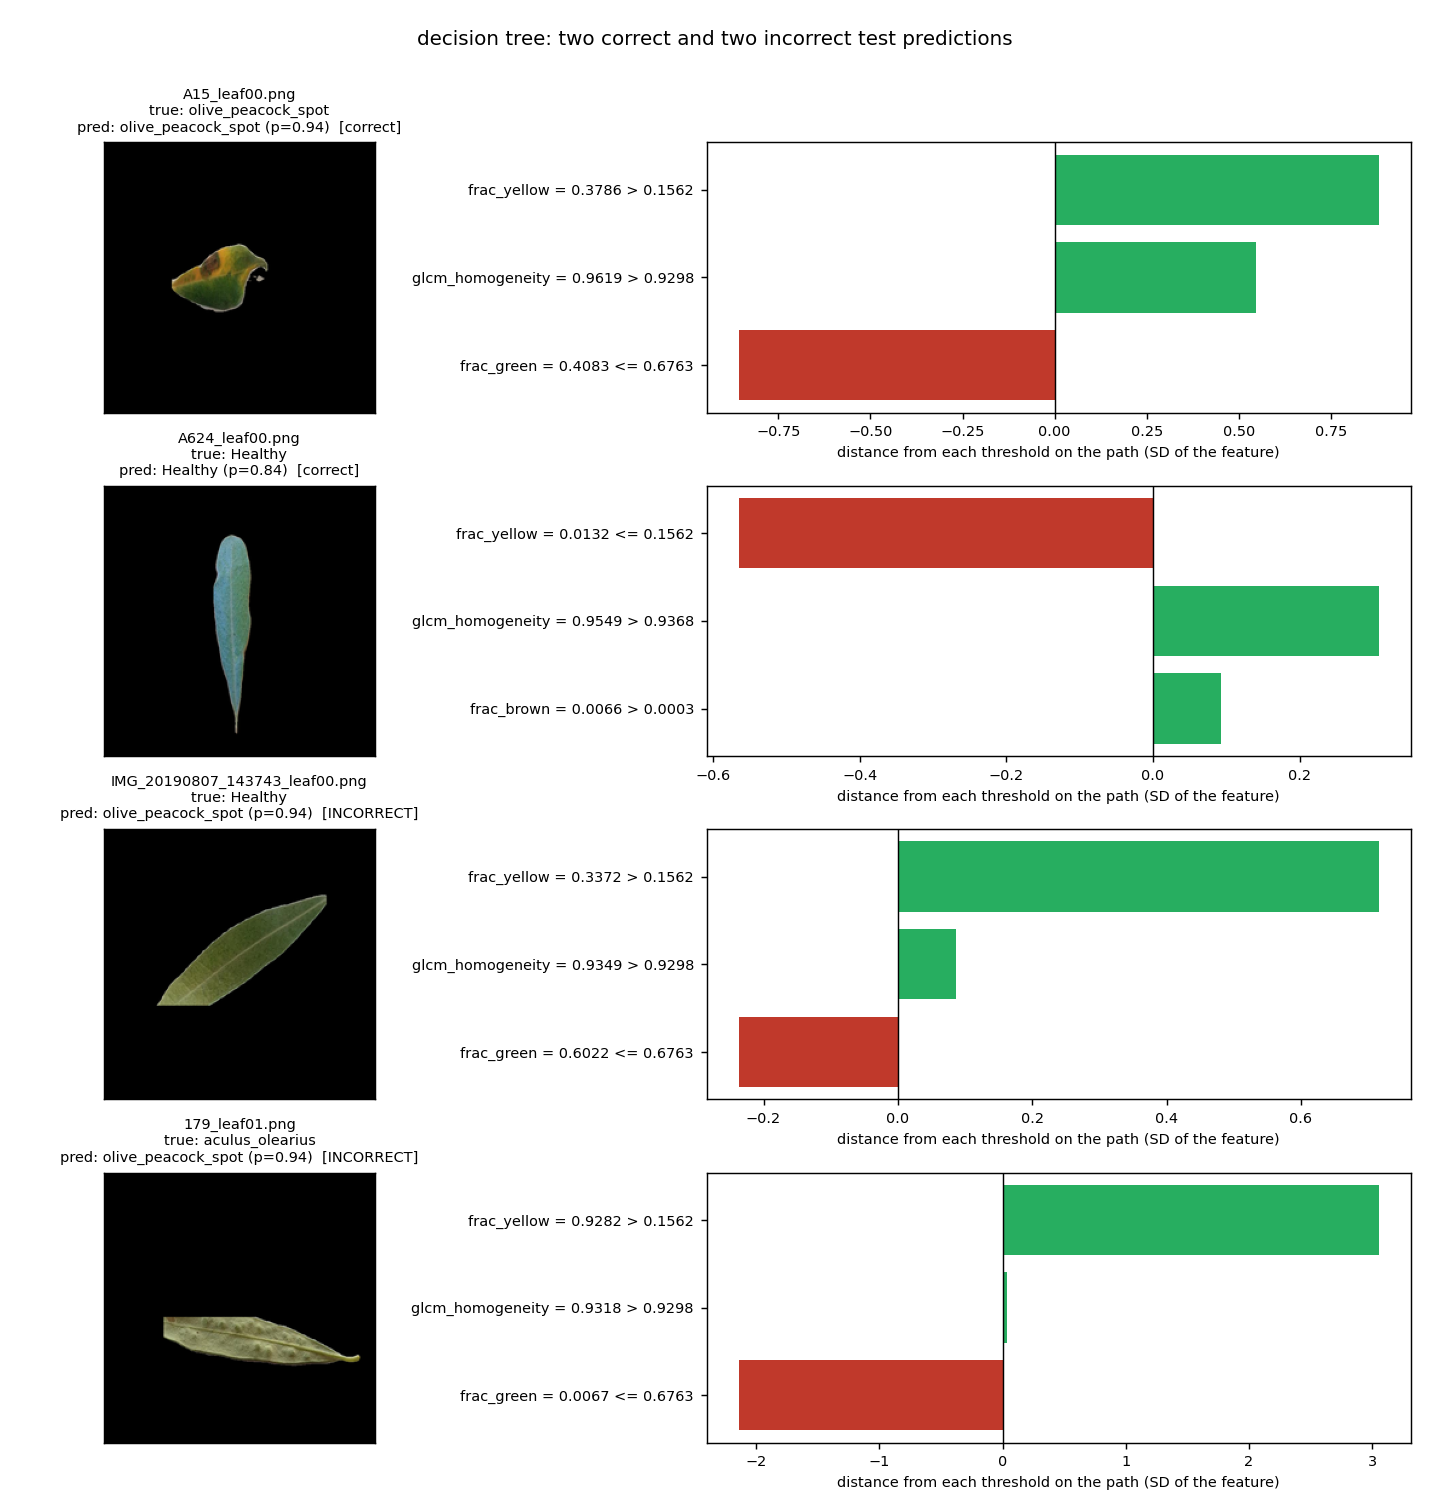

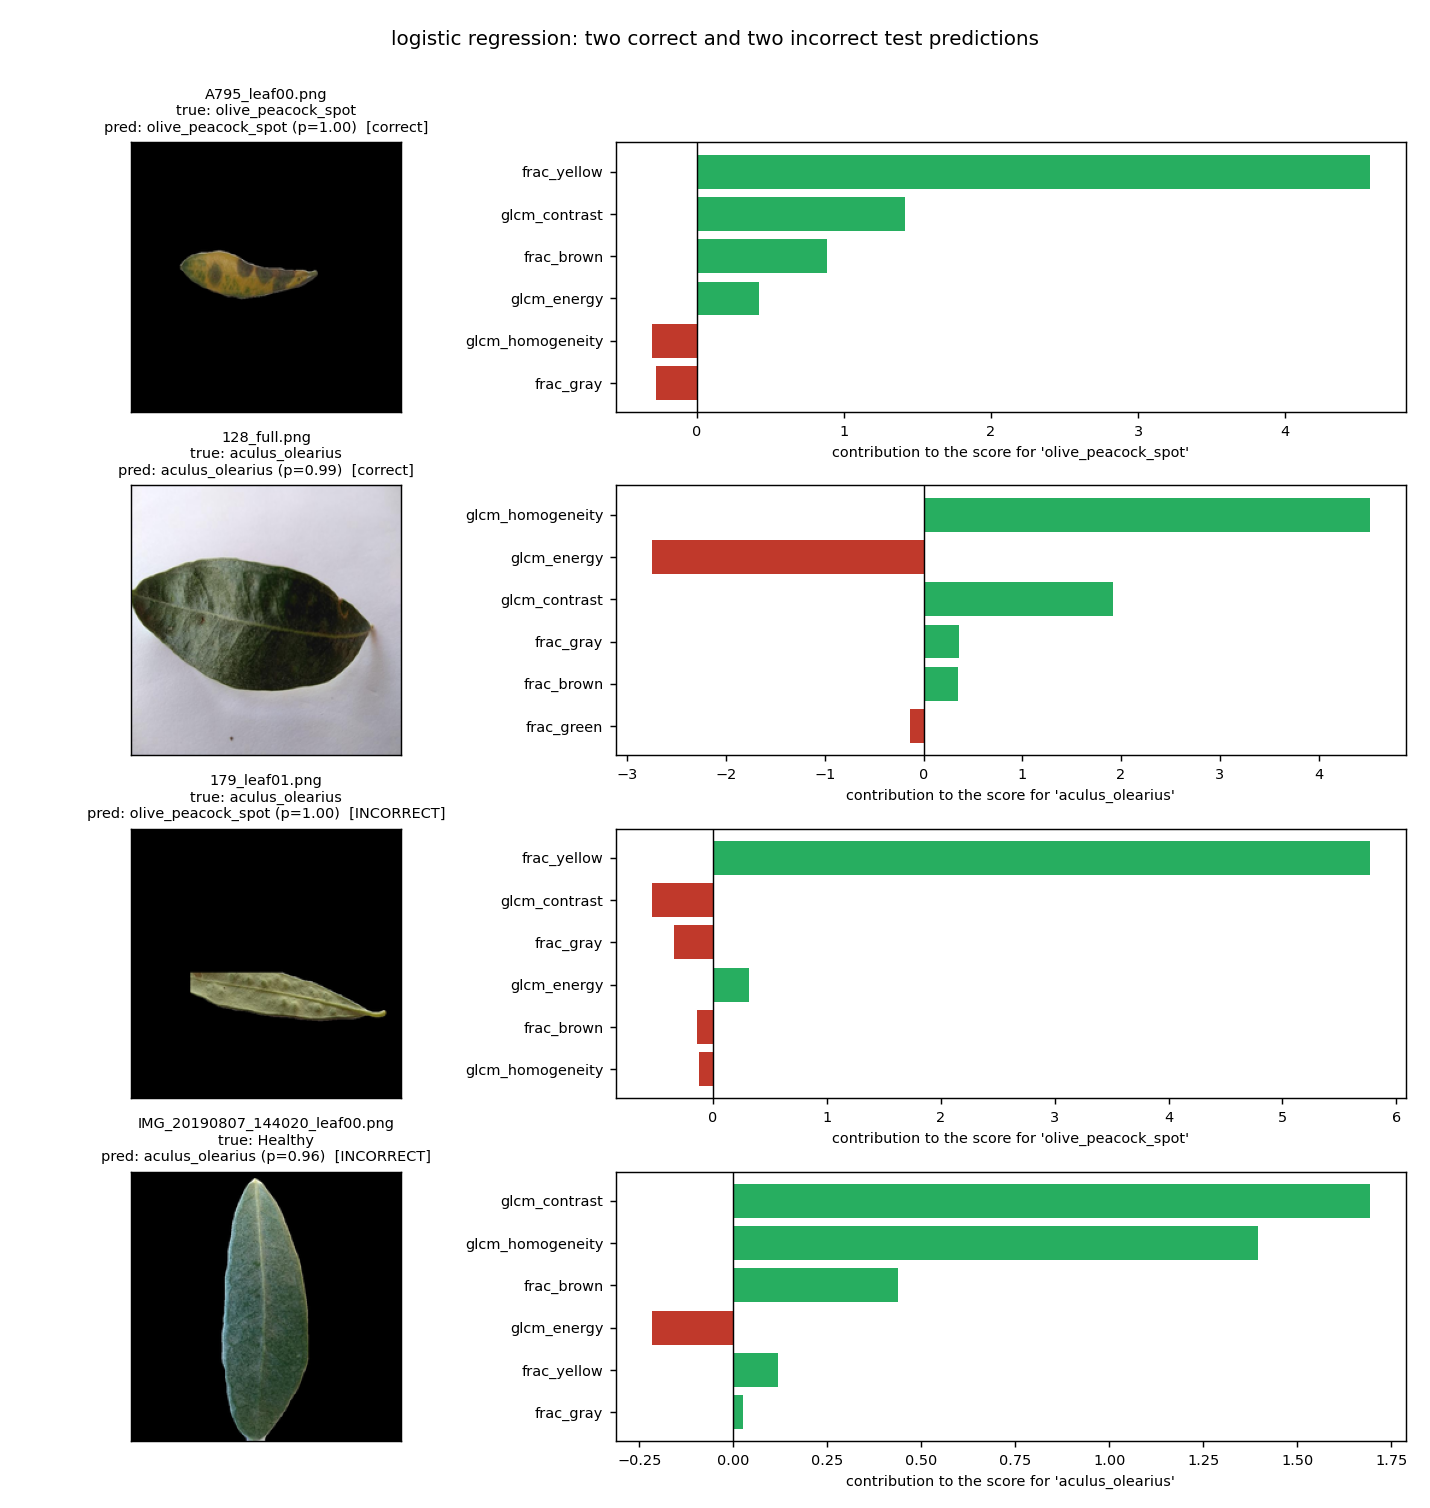

true  \
model               file                                                 
decision tree       A15_leaf00.png                  olive_peacock_spot   
                    A624_leaf00.png                            Healthy   
                    IMG_20190807_143743_leaf00.png             Healthy   
                    179_leaf01.png                     aculus_olearius   
logistic regression A795_leaf00.png                 olive_peacock_spot   
                    128_full.png                       aculus_olearius   
                    179_leaf01.png                     aculus_olearius   
                    IMG_20190807_144020_leaf00.png             Healthy   

                                                             predicted  \
model               file                                                 
decision tree       A15_leaf00.png                  olive_peacock_spot   
                    A624_leaf00.png                            Healthy   
                    IMG_20190807_143743_leaf00.png  olive_peacock_spot   
                    179_leaf01.png                  olive_peacock_spot   
logistic regression A795_leaf00.png                 olive_peacock_spot   
                    128_full.png                       aculus_olearius   
                    179_leaf01.png                  olive_peacock_spot   
                    IMG_20190807_144020_leaf00.png     aculus_olearius   

                                                    confidence  correct  
model               file                                                 
decision tree       A15_leaf00.png                       0.945     True  
                    A624_leaf00.png                      0.843     True  
                    IMG_20190807_143743_leaf00.png       0.945    False  
                    179_leaf01.png                       0.945    False  
logistic regression A795_leaf00.png                      1.000     True  
                    128_full.png                         0.994     True  
                    179_leaf01.png                       0.996    False  
                    IMG_20190807_144020_leaf00.png       0.963    False

In [13]:
for model in ('decision_tree', 'logistic_regression'):
    found = needs(ANALYSIS_RESULTS / ('glassbox_fixed_%s_examples.png' % model),
                  hint='enable RUN_ANALYSIS')
    if found:
        display(DisplayImage(filename=str(found[0])))

if 'segmented' in glassbox:
    errors = pd.DataFrame([
        {'model': model.replace('_', ' '), 'file': case['file'],
         'true': case['true_class'], 'predicted': case['predicted_class'],
         'confidence': round(case['confidence'], 3),
         'correct': case['correct']}
        for model, cases in glassbox['segmented']['explanations'].items()
        for case in cases
    ])
    display(errors.set_index(['model', 'file']))

## 5. RQ a: the like-for-like comparison

The three families can only be compared on a common test set. The table below
restricts every model to the official 680-image test split: the deep models are
scored there by construction, and the glass-box models are scored there through
the `common` protocol. The segmented-crop glass-box numbers from section 4 are
*not* comparable to these and are excluded on purpose.

In [14]:
comparison = []
for name, training, filename in DEEP_MODELS:
    path = COMPRESSION_RESULTS / filename
    if not path.exists():
        continue
    result = load_json(path)
    comparison.append({
        'model': name, 'family': training,
        'parameters': result['total_parameters'],
        'accuracy': result['metrics']['test']['accuracy'],
        'macro-F1': result['metrics']['test']['macro_f1'],
        'interpretability': 'post-hoc (Grad-CAM / LIME)',
    })

if 'common' in glassbox:
    for model in ('decision_tree', 'logistic_regression'):
        comparison.append({
            'model': model.replace('_', ' ') + ' (engineered features)',
            'family': 'glass-box',
            'parameters': len(glassbox['common']['features']),
            'accuracy': glassbox['common'][model]['accuracy'],
            'macro-F1': glassbox['common'][model]['macro_f1'],
            'interpretability': 'intrinsic (exact)',
        })

comparison_table = pd.DataFrame(comparison).set_index('model')
display(comparison_table.style.format(
    {'accuracy': '{:.4f}', 'macro-F1': '{:.4f}', 'parameters': '{:,.0f}'}))

,family,parameters,accuracy,macro-F1,interpretability
model,,,,,
scratch CNN (notebook architecture),from scratch,"5,767,139",0.8118,0.8095,post-hoc (Grad-CAM / LIME)
scratch CNN (redesigned),from scratch,"585,059",0.8706,0.8712,post-hoc (Grad-CAM / LIME)
MobileNetV2,ImageNet transfer,"2,261,827",0.9309,0.9296,post-hoc (Grad-CAM / LIME)
DenseNet121,ImageNet transfer,"7,040,579",0.9397,0.9387,post-hoc (Grad-CAM / LIME)
decision tree (engineered features),glass-box,9,0.6838,0.6674,intrinsic (exact)
logistic regression (engineered features),glass-box,9,0.6206,0.5999,intrinsic (exact)


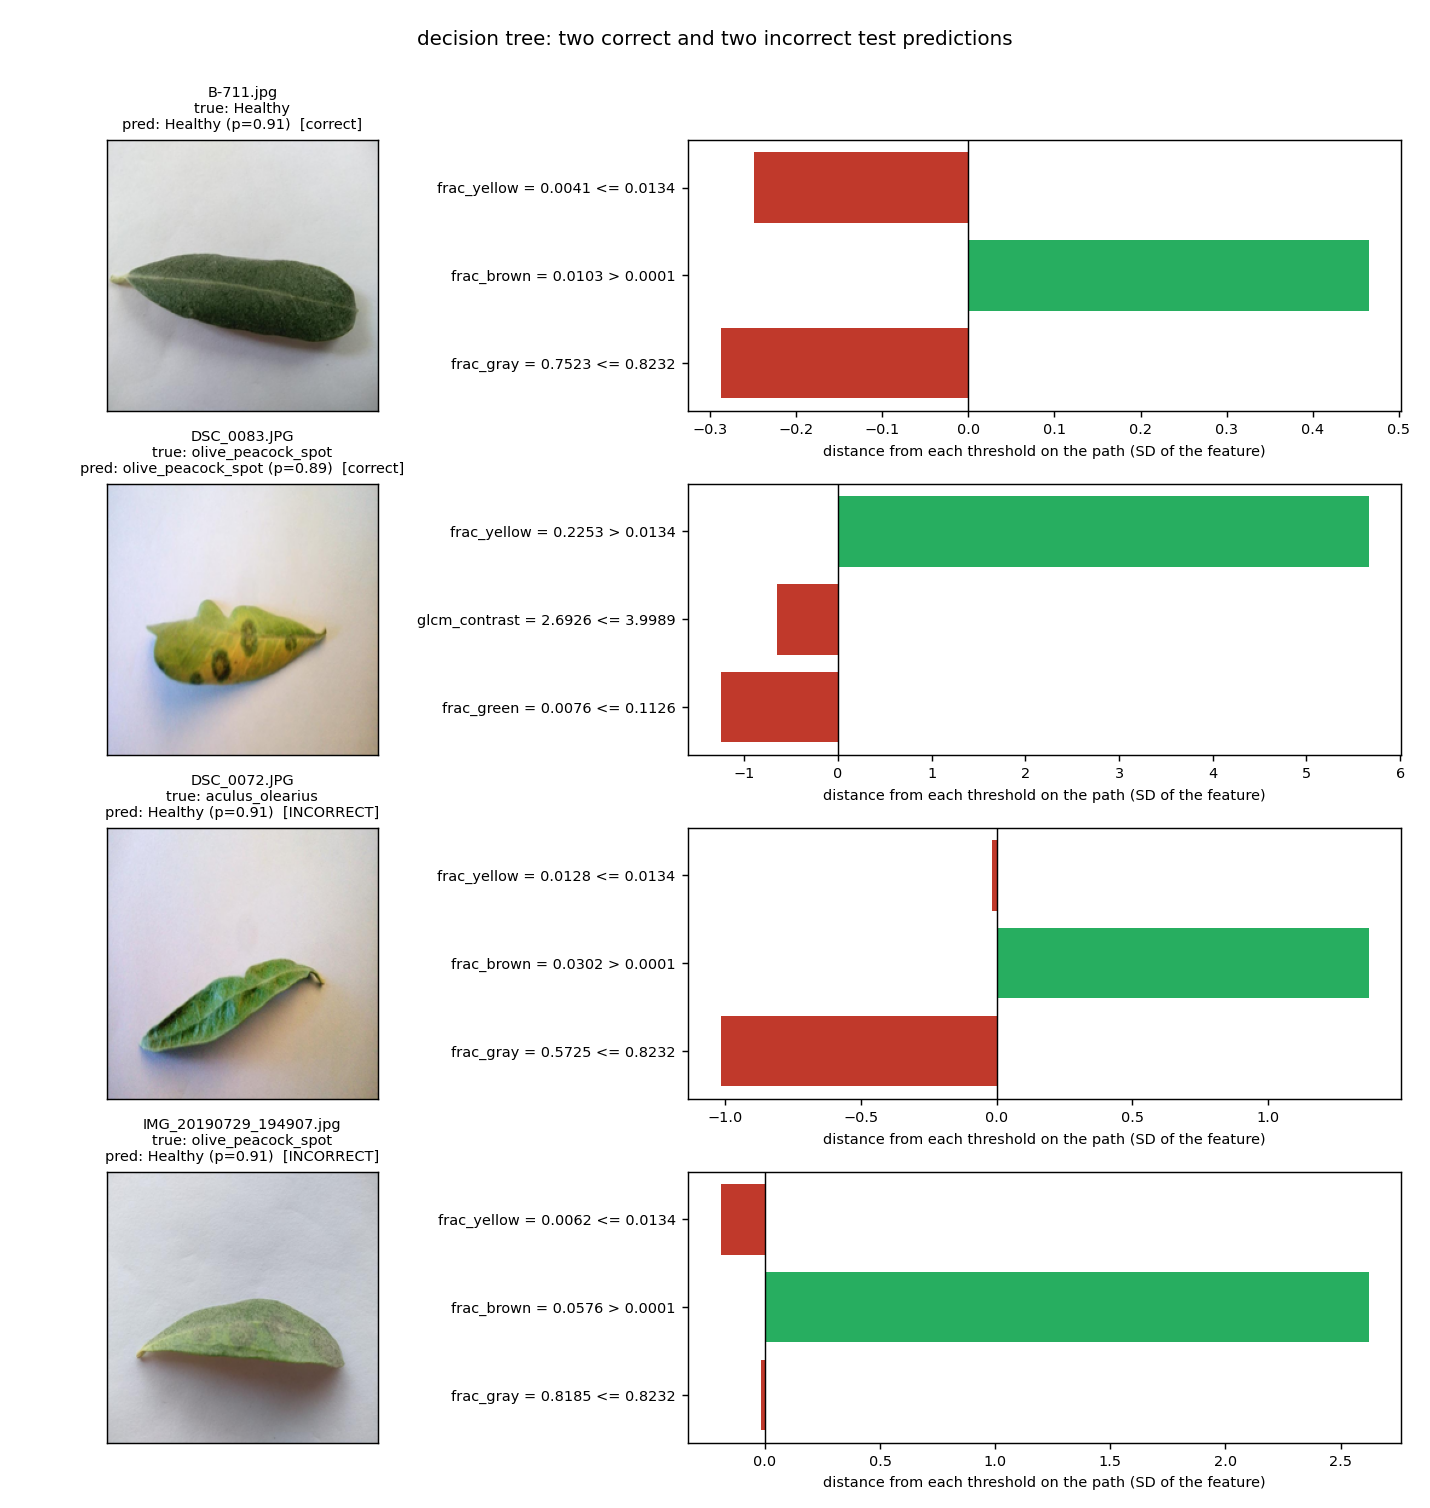

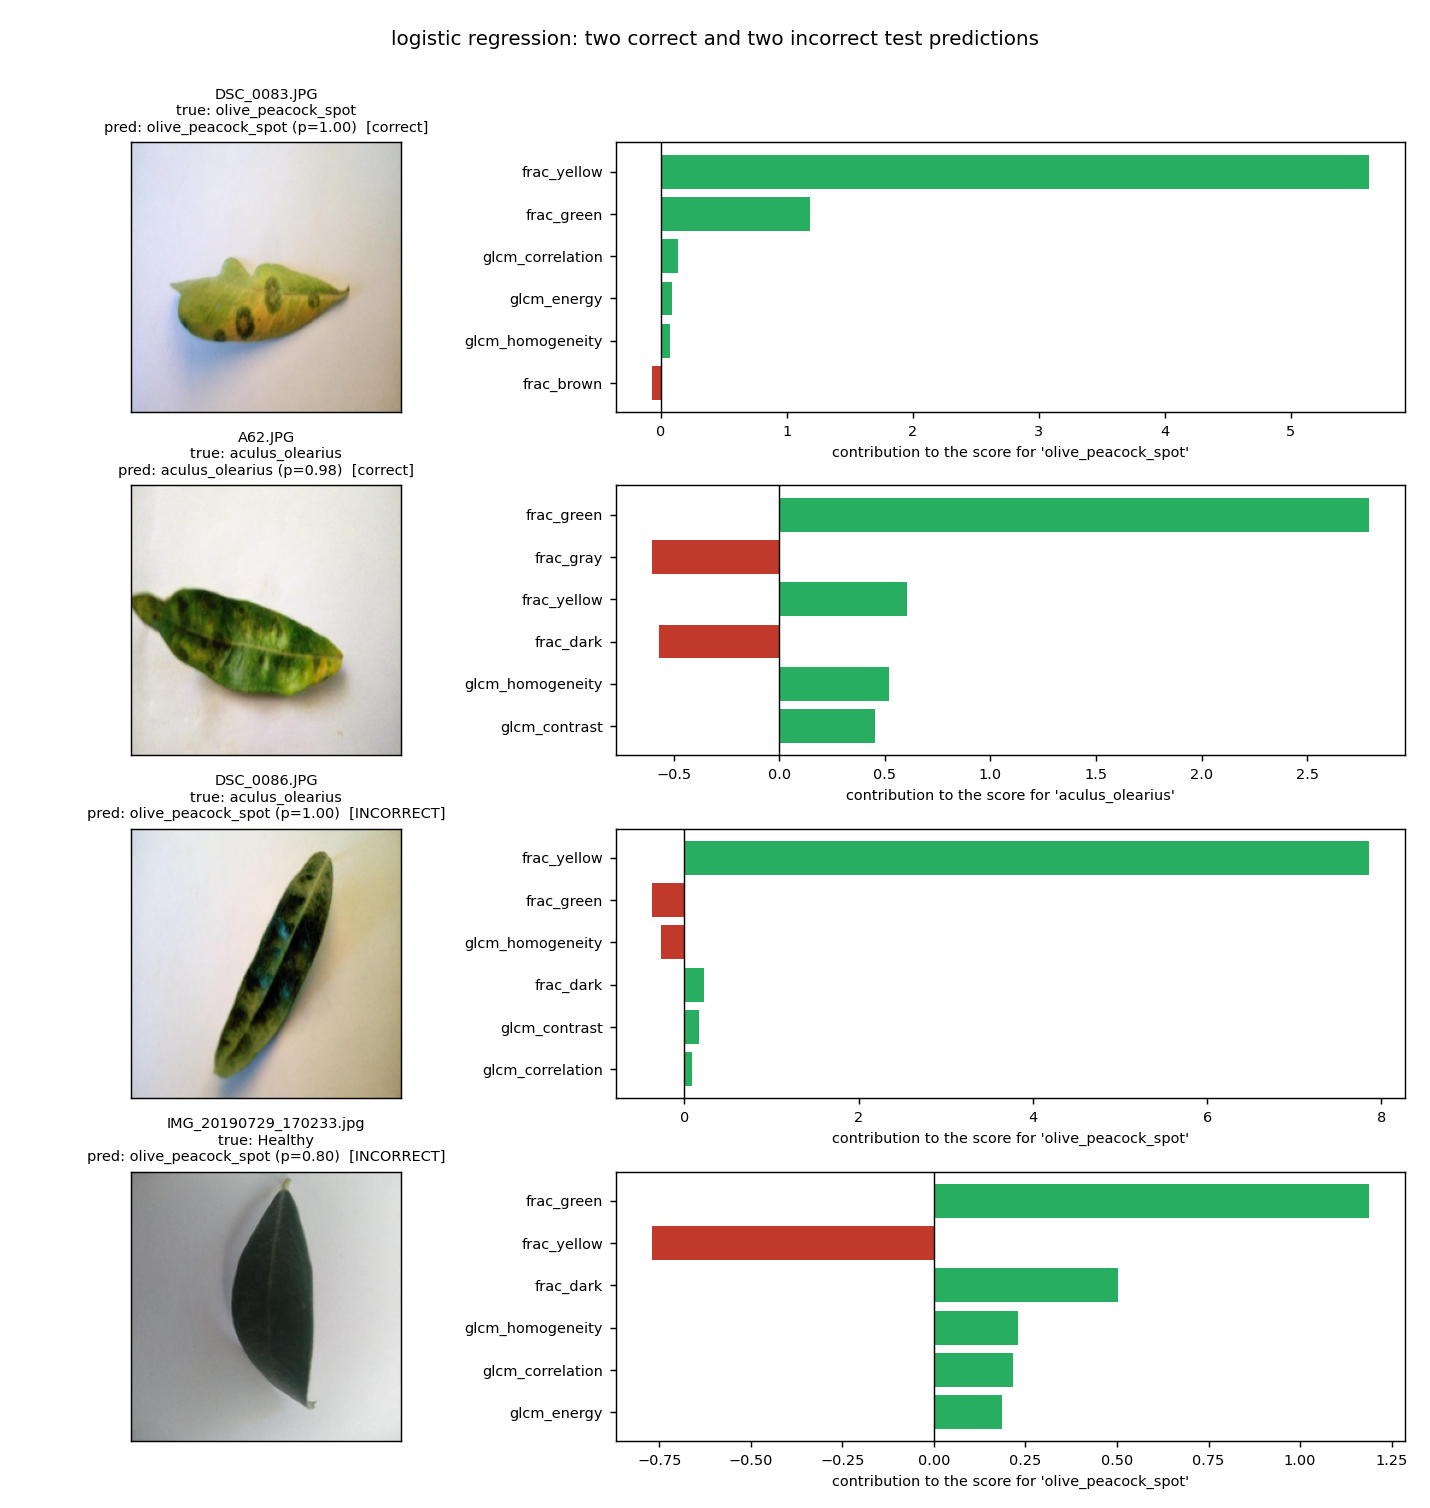

In [15]:
# The same four-case explanation, on the test set used for the comparison above.
for model in ('decision_tree', 'logistic_regression'):
    found = needs(ANALYSIS_RESULTS / ('glassbox_common_protocol_%s_examples.png' % model),
                  hint='enable RUN_ANALYSIS')
    if found:
        display(DisplayImage(filename=str(found[0])))

> **To write up.** Interpret this table rather than restating it: what the
> from-scratch/transfer gap costs, what the glass-box models give up for an exact
> explanation, and whether the `parameters` column is even a fair axis to compare
> nine engineered features against millions of weights.

## 6. Model compression

The authoritative implementations are `compression/src/prune.py`,
`prune_sweep.py`, `quantise.py`, and `measure.py`. They apply magnitude pruning,
TFLite dynamic-range/float16/full-integer quantisation, common validation/test
evaluation, and single-thread CPU latency measurement.

In [16]:
if RUN_COMPRESSION:
    # These are the same ordered stages as pipeline.sh, run directly because
    # this notebook is already executing inside the course container.
    sweep = {
        'mobilenetv2': ('0.2', '0.35', '0.5', '0.65'),
        'densenet121': ('0.5', '0.65', '0.8', '0.9'),
    }
    for backbone in BACKBONES:
        run_source(COMPRESSION_DIR, 'src/quantise.py', '--backbone', backbone)
        run_source(COMPRESSION_DIR, 'src/prune.py', '--backbone', backbone, '--sparsity', '0.5')
        run_source(
            COMPRESSION_DIR, 'src/quantise.py', '--backbone', backbone,
            '--tag', 'pruned50', '--variants', 'dynamic_range', 'float16',
        )
        run_source(
            COMPRESSION_DIR, 'src/prune_sweep.py', '--backbone', backbone,
            '--sparsities', *sweep[backbone],
        )
        run_source(COMPRESSION_DIR, 'src/measure.py', '--backbone', backbone)
        run_source(COMPRESSION_DIR, 'src/xai_fidelity.py', '--backbone', backbone)
    run_source(COMPRESSION_DIR, 'src/plot_results.py')

mobilenetv2


,variant,size_mb,gzip_mb,latency_median_ms,throughput_img_s,test_macro_f1,test_recall_aculus
0,mobilenetv2_baseline,13.211,8.738,53.550,18.700,0.930,0.885
1,mobilenetv2_pruned50,13.240,5.540,51.690,19.300,0.706,0.690
2,mobilenetv2_sweep20,13.240,7.619,51.980,19.200,0.920,0.860
3,mobilenetv2_sweep35,13.240,6.636,51.930,19.300,0.889,0.895
4,mobilenetv2_sweep50,13.240,5.545,52.100,19.200,0.833,0.770
5,mobilenetv2_sweep65,13.240,4.397,52.750,19.000,0.534,0.725
6,mobilenetv2_baseline_dynamic_range,2.512,2.159,18.630,53.700,0.934,0.890
7,mobilenetv2_baseline_float16,4.479,4.113,11.160,89.600,0.928,0.885
8,mobilenetv2_baseline_float32,8.882,8.234,11.560,86.500,0.930,0.885
9,mobilenetv2_baseline_full_integer,2.715,2.210,9.480,105.500,0.924,0.875


densenet121


,variant,size_mb,gzip_mb,latency_median_ms,throughput_img_s,test_macro_f1,test_recall_aculus
0,densenet121_baseline,38.148,27.061,119.580,8.400,0.939,0.970
1,densenet121_pruned50,38.212,16.519,118.320,8.500,0.947,0.965
2,densenet121_sweep50,38.212,16.526,119.100,8.400,0.945,0.990
3,densenet121_sweep65,38.229,12.924,119.200,8.400,0.934,0.955
4,densenet121_sweep80,38.229,8.971,118.310,8.500,0.829,0.810
5,densenet121_sweep90,38.229,6.139,119.470,8.400,0.667,0.745
6,densenet121_baseline_dynamic_range,7.421,6.009,106.660,9.400,0.931,0.970
7,densenet121_baseline_float16,14.061,12.943,109.720,9.100,0.939,0.970
8,densenet121_baseline_float32,27.915,26.080,110.280,9.100,0.939,0.970
9,densenet121_baseline_full_integer,7.362,5.858,57.470,17.400,0.868,0.855


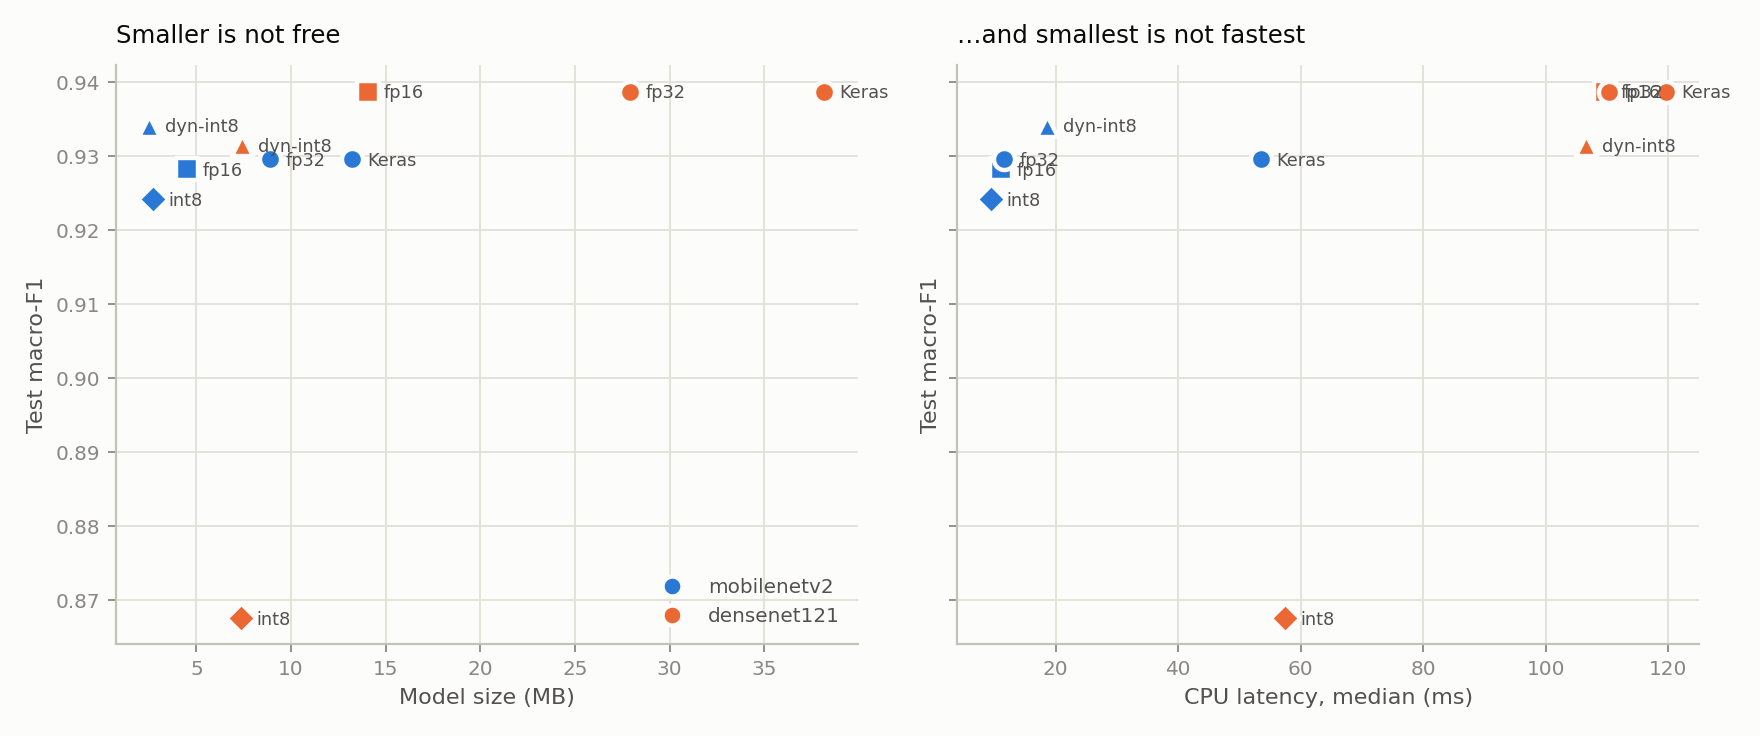

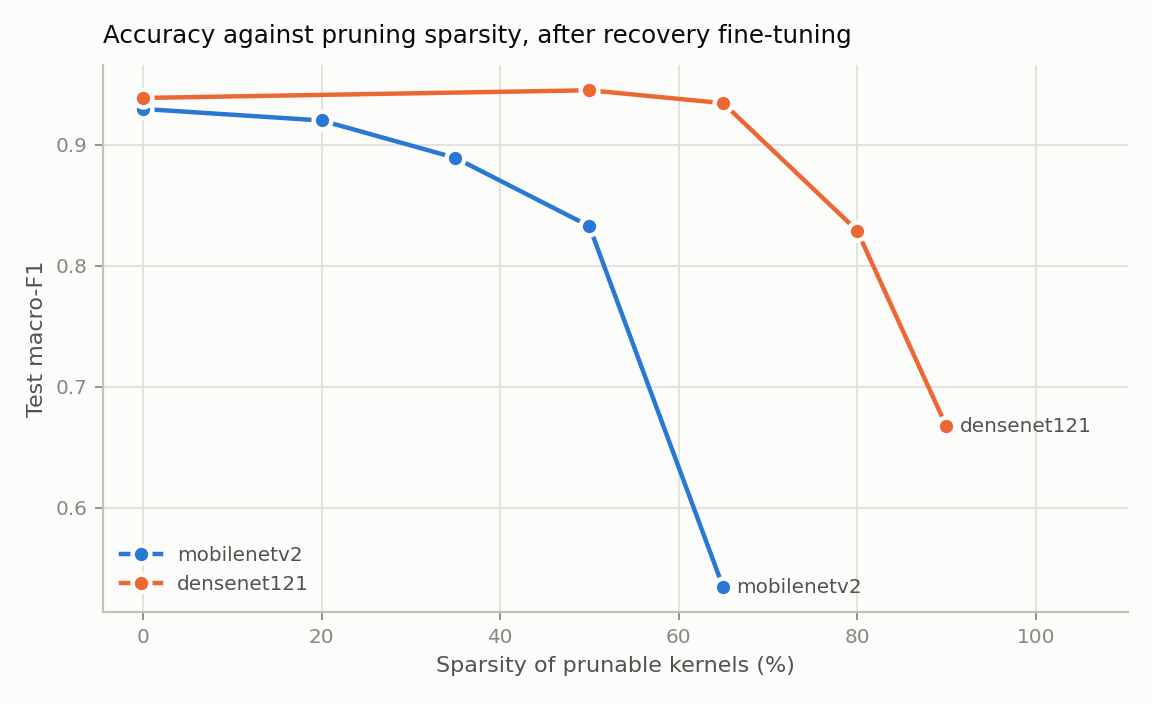

In [17]:
KEEP = ['variant', 'size_mb', 'gzip_mb', 'latency_median_ms',
        'throughput_img_s', 'test_macro_f1', 'test_recall_aculus']

for backbone in BACKBONES:
    found = needs(COMPRESSION_RESULTS / ('%s_compression_table.csv' % backbone),
                  hint='enable RUN_COMPRESSION')
    if found:
        print(backbone)
        display(pd.read_csv(found[0])[KEEP].style.format(precision=3))

for figure in ('compression_tradeoff.png', 'pruning_sweep.png'):
    found = needs(COMPRESSION_RESULTS / figure, hint='enable RUN_COMPRESSION')
    if found:
        display(DisplayImage(filename=str(found[0])))

## 7. XAI: correct and incorrect predictions, and compression fidelity

`analysis/gradcam_report.py` deliberately selects two correct and two incorrect
DenseNet121 predictions per class and annotates true class, predicted class, and
confidence -- the black-box counterpart to the glass-box cases in sections 4 and
5. `compression/src/xai_fidelity.py` uses the same LIME procedure for the Keras
baseline and each TFLite variant, because TFLite does not expose gradients.

In [18]:
if RUN_ANALYSIS:
    run_source(
        ANALYSIS_DIR, 'gradcam_report.py',
        '--model', '../compression/artifacts/densenet121_baseline',
    )
    run_source(
        ANALYSIS_DIR, 'acquisition_bias.py',
        '--model', '../compression/artifacts/mobilenetv2_baseline',
    )
    run_source(COMPRESSION_DIR, 'src/xai_fidelity.py', '--backbone', 'mobilenetv2')

prediction type,correct,incorrect
class,,
Healthy,2,2
aculus_olearius,2,2
olive_peacock_spot,2,2


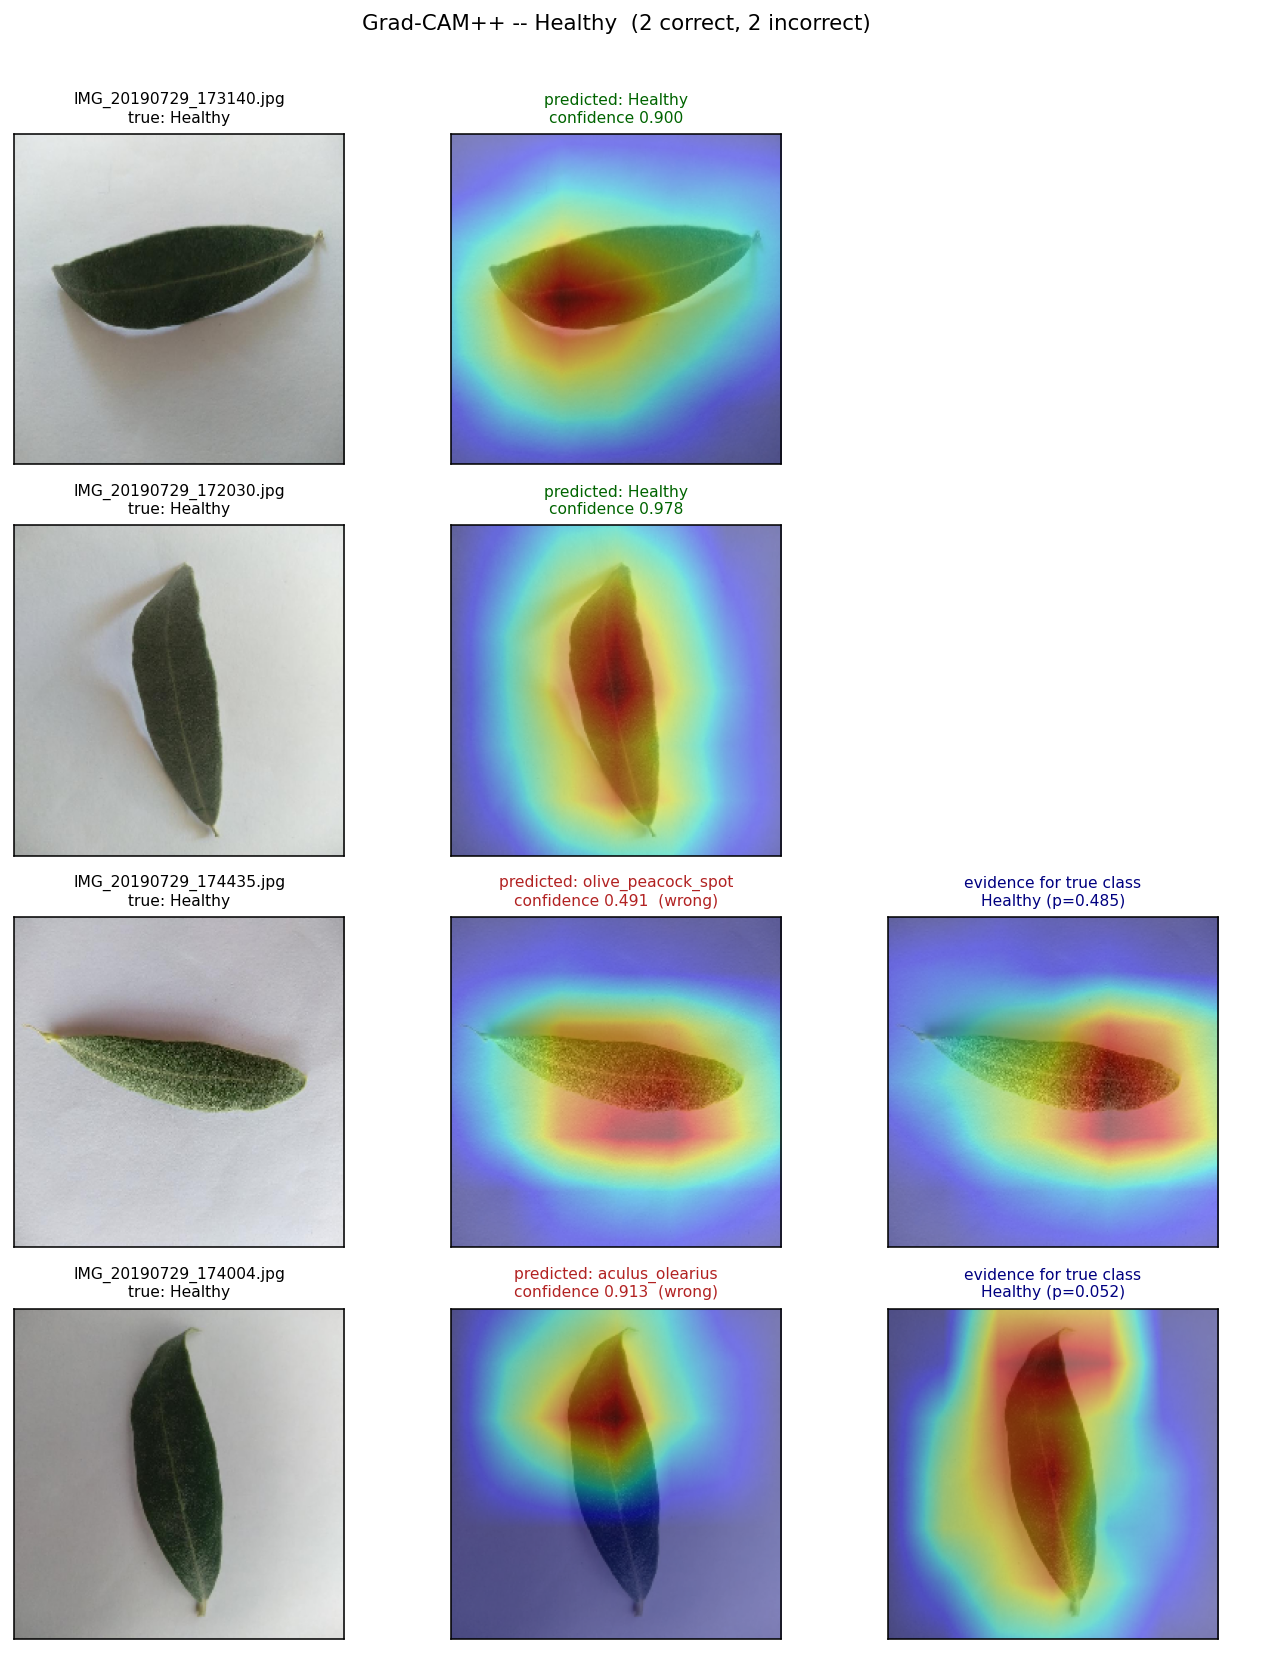

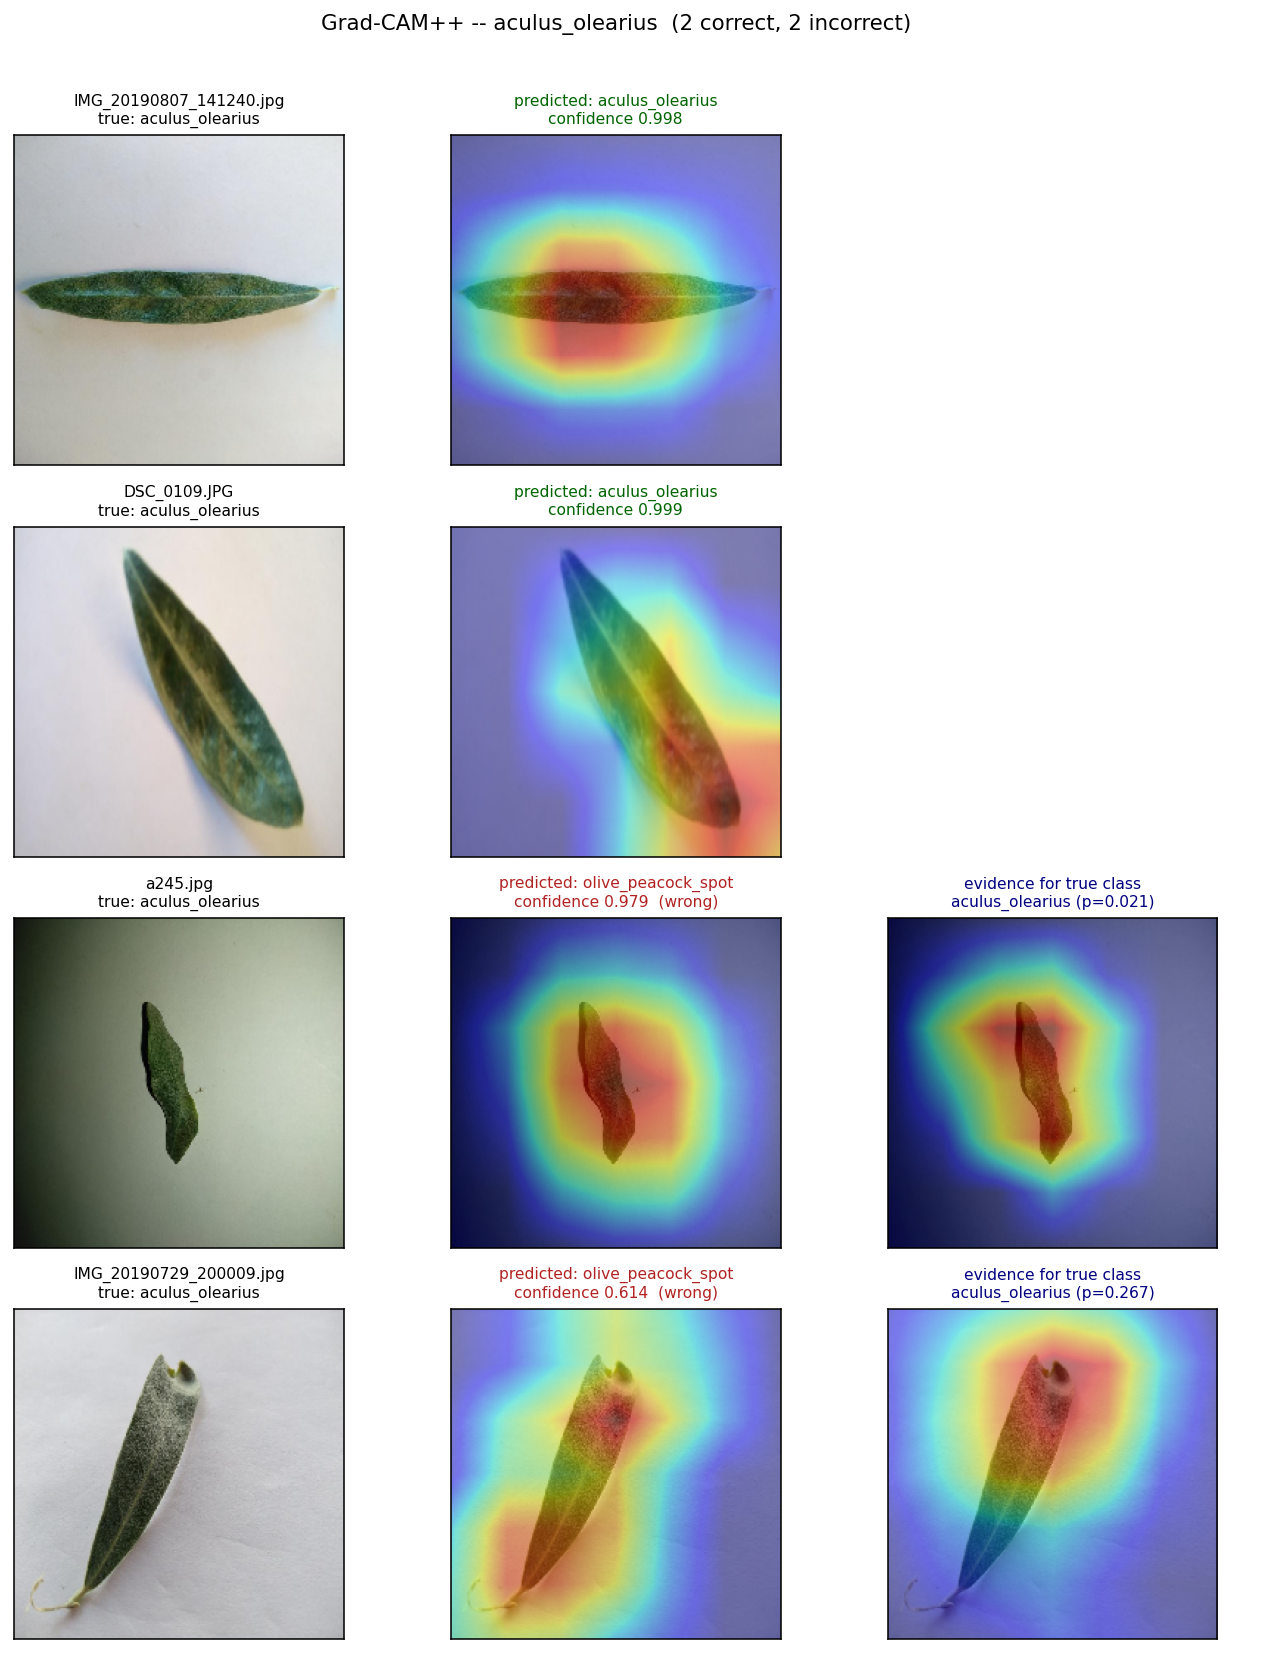

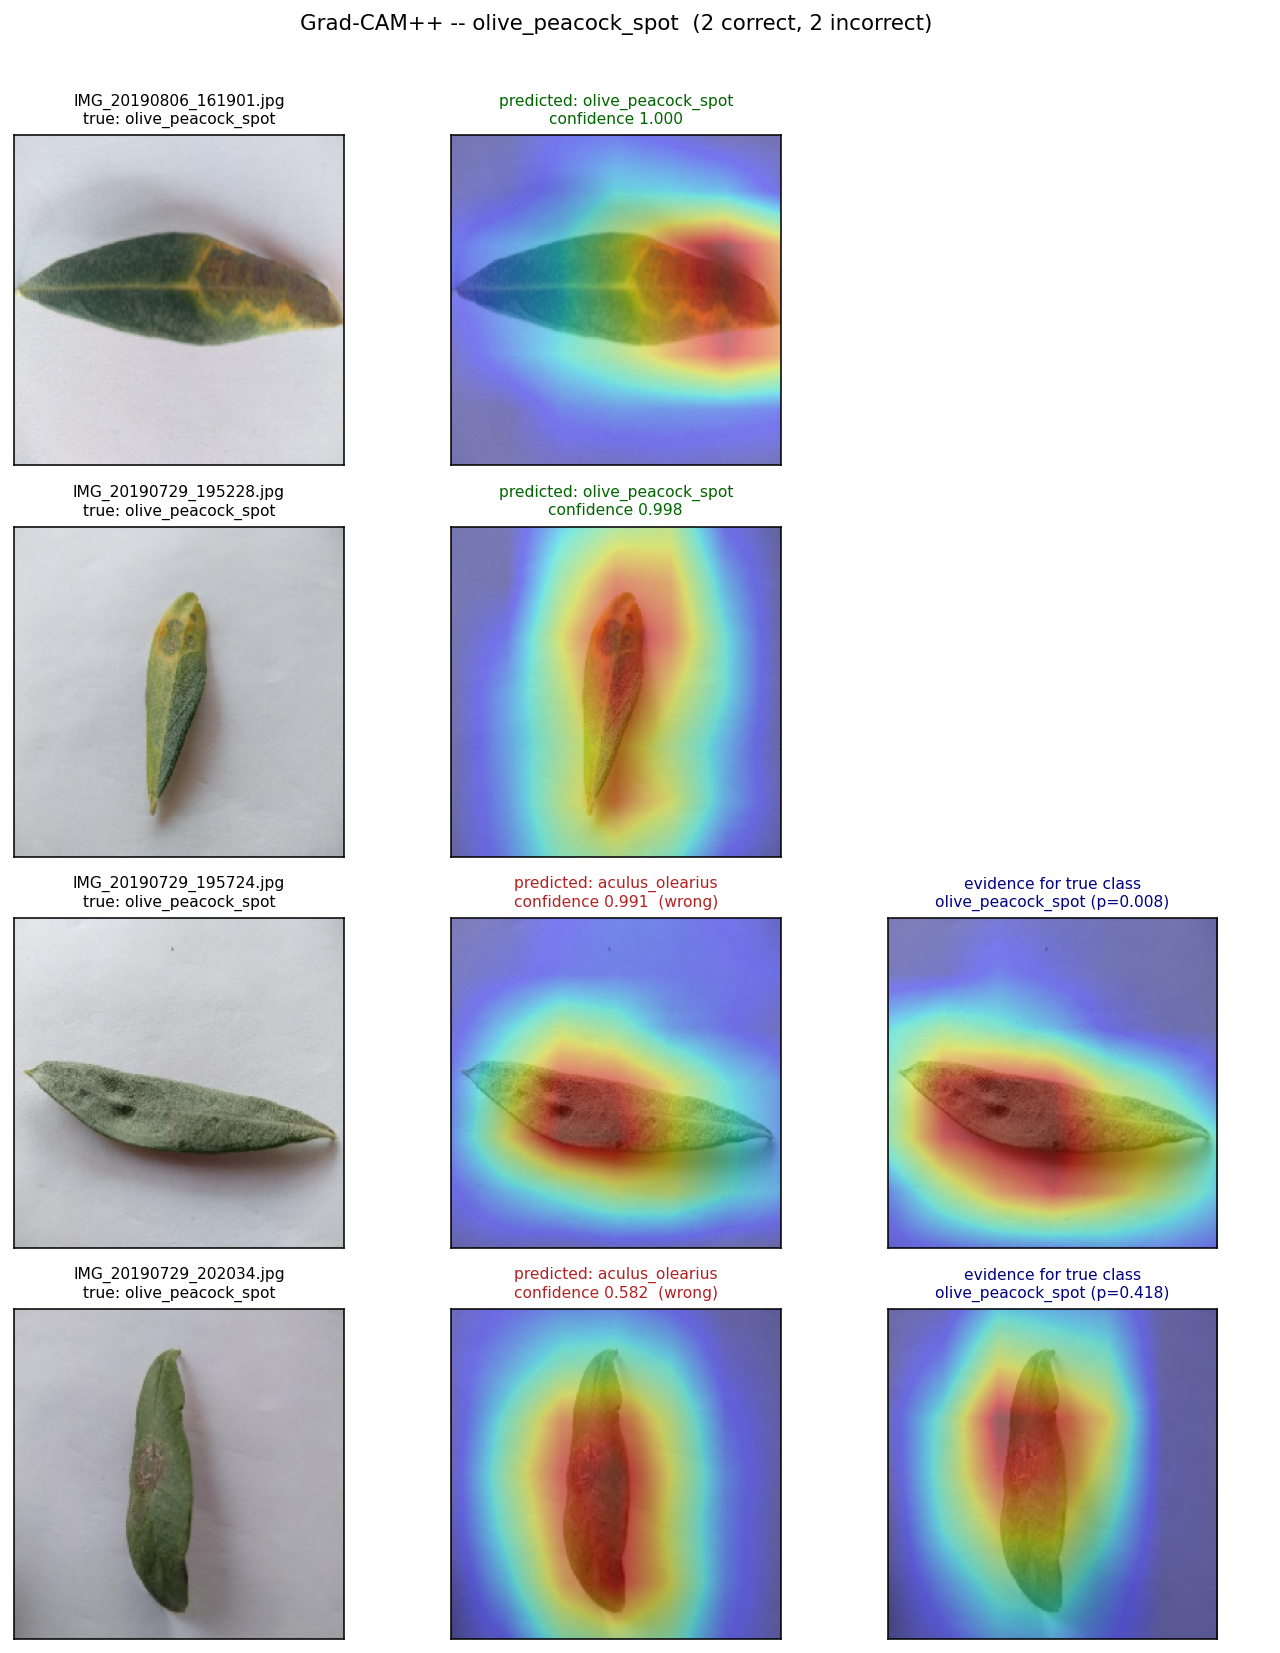

In [19]:
found = needs(ANALYSIS_RESULTS / 'gradcam_report.json', hint='enable RUN_ANALYSIS')
if found:
    gradcam = load_json(found[0])
    panel_counts = Counter(
        (row['true_class'], 'correct' if row['correct'] else 'incorrect')
        for row in gradcam['panels']
    )
    display(pd.Series(panel_counts, name='examples')
            .rename_axis(['class', 'prediction type']).unstack(fill_value=0))

for class_name in CLASSES:
    found = needs(ANALYSIS_RESULTS / ('gradcam_%s.png' % class_name),
                  hint='enable RUN_ANALYSIS')
    if found:
        display(DisplayImage(filename=str(found[0])))

In [20]:
found = needs(COMPRESSION_RESULTS / 'mobilenetv2_xai_fidelity.json',
              hint='enable RUN_COMPRESSION')
if found:
    fidelity = load_json(found[0])
    fidelity_table = pd.DataFrame(fidelity['summary']).T
    fidelity_table.index.name = 'quantisation variant'
    display(fidelity_table.style.format(precision=3))

,images,mean_spearman,mean_top5_jaccard,label_agreement_rate
quantisation variant,,,,
dynamic_range,6.000,0.556,0.548,0.833
float16,6.000,0.599,0.833,1.000
full_integer,6.000,0.407,0.627,1.000


## 8. Acquisition bias and model drift

`analysis/acquisition_bias.py` tests two separate questions: whether capture
source is entangled with the class label, and whether Grad-CAM++ attention
actually falls outside the leaf.

In [21]:
found = needs(ANALYSIS_RESULTS / 'acquisition_bias.json', hint='enable RUN_ANALYSIS')
if found:
    bias = load_json(found[0])
    display(pd.DataFrame(bias['part_a']['source_class_table']))

    attention = pd.DataFrame([{
        'model': bias['part_b']['model'],
        'images': bias['part_b']['n_correct'] + bias['part_b']['n_incorrect'],
        'attention outside leaf': bias['part_b']['mean_attention_outside_leaf'],
        'background area': bias['part_b']['mean_background_area'],
        'all ratio': bias['part_b']['background_preference_ratio'],
        'correct ratio': bias['part_b']['background_preference_ratio_correct'],
        'incorrect ratio': bias['part_b']['background_preference_ratio_incorrect'],
    }])
    display(attention.style.format(precision=3))

,test/Healthy,test/aculus_olearius,test/olive_peacock_spot,train/Healthy,train/aculus_olearius,train/olive_peacock_spot
B* (camera roll),79.0,NaN,NaN,609.0,NaN,1.0
DSC_ (DSLR),4.0,37.0,7.0,4.0,NaN,15.0
"IMG_ (phone, timestamped)",137.0,154.0,253.0,189.0,NaN,962.0
A* (camera roll),NaN,9.0,NaN,28.0,NaN,222.0
bare numeric,NaN,NaN,NaN,NaN,690.0,NaN


,model,images,attention outside leaf,background area,all ratio,correct ratio,incorrect ratio
0,../compression/artifacts/mobilenetv2_baseline,75,0.109,0.155,0.704,0.706,0.671


### Model drift: what to monitor, and what to do about it

The two measurements above are not only an audit of the current model; they are
the baseline a deployed system would be monitored against. Concretely:

**What would drift, and why.** The dominant risk here is not gradual concept
drift in the disease itself but a change in *capture conditions*. Capture source
is heavily entangled with label in this dataset — the `bare numeric` block is
100% `aculus_olearius` and the `B*` block is 99.8% `Healthy` — and a classifier
given nothing but the filename prefix reaches 91.8% on training data against a
38.2% majority baseline. A deployment that switched camera, season, or lighting
would move the input distribution along exactly the axis the training data
confounds with the label. Note the same probe reaches only 49.9% on the official
test split, which is itself evidence that the train and test photographs were
captured differently.

**What to monitor.** Three signals, in increasing cost:

| signal | source | why it is the right signal |
|---|---|---|
| input statistics — per-channel colour distribution, image dimensions, EXIF device | `analysis/dataset_audit.py` computes these already | detects a capture change *before* any label is available |
| prediction distribution and confidence | inference logs | a shift in predicted class mix, or a rise in low-confidence outputs, needs no ground truth |
| attention outside the leaf mask | `analysis/acquisition_bias.py` part B | the model currently places 10.9% of its Grad-CAM++ mass outside a leaf that occupies 15.5% of the frame, a ratio of **0.70**; a ratio drifting toward or above 1.0 means it has started reading background |

**When to call it drift.** The honest answer is that this project has one
measurement per signal, not a distribution of them, so it can set a baseline but
not a threshold. A defensible protocol is to re-measure the three signals on each
new batch, treat a sustained move as the trigger rather than a single batch, and
size the tolerance from the variation seen across the existing capture sources —
which the per-source table above gives, and which is wide.

**What to do when it triggers.** Escalating, and the choice depends on which
signal moved. Input statistics alone → re-measure the attention ratio on the new
batch before acting, since a new camera is not by itself a failure. Attention
ratio rising → the model is reading background; retraining on data that includes
the new capture conditions is the remedy, and re-labelling is not, because the
labels are not what changed. Confidence collapsing or the class mix shifting
without an input-side explanation → suspend the deployment and get expert
labels on a sample, because at that point the failure mode is unknown. The
triage framing in `draft-ethics.md` matters here: a triage tool that degrades
wastes an agronomist's time, which is recoverable, and that is why the framing
was chosen over a diagnostic claim.

## 9. Final-submission completion checklist

The executable evidence is connected in one notebook and every research question
now has a fair comparison behind it. Before exporting HTML/PDF, the team still
needs to:

- add its own rationale and interpretation after every results cell -- the
  markdown here describes *what* was run, not what the team concludes from it;
- add the literature review, ethical decisions, model-drift discussion,
  conclusion, references, AI-use declaration, and individual contributions;
- resolve the four `[team decision]` items in `draft-ethics.md`;
- restart the kernel, run all cells without errors, and export the executed
  notebook to HTML or PDF.